# Exploratory Data Analysis
### Shipping Reliability Simulator — Rotterdam → Singapore → Shanghai

**Why only 3 ports?**
The project models a single specific trade lane — Rotterdam → Singapore → Shanghai. That lane was chosen deliberately, not arbitrarily. It represents:

- One of the highest-volume container routes in the world — the Europe–Asia trade lane accounts for roughly 25–30% of global container trade
- A route with real operational complexity — three genuinely different port environments, different congestion patterns, different disruption risk profiles

**Datasets:**
| File | Source | Description |
|---|---|---|
| `daily_ports.csv` | IMF PortWatch | Daily vessel calls per port (2019–2026) |
| `disruptions.csv` | IMF PortWatch | Global disruption events affecting ports |
| `port_calls.csv` | UNCTAD | Annual median time in port, container ships |
| `port_calls_arr.csv` | UNCTAD | Annual number of port calls, container ships |

**Key facts discovered in data exploration:**
- Shanghai appears as two terminals: `Shanghai (Pudong)` and `Shanghai (Yangshan)` → use Yangshan (largest container terminal)
- UNCTAD economy codes: China=156, Netherlands=528, Singapore=702
- Container ships = `CommercialMarket == 3` (integer, not string `'03'`)
- Singapore UNCTAD time-in-port data is NaN for 2018–2021, available only for 2022–2023
- Disruptions `affectedports` uses semicolon-separated portids (not space-separated)
- Port IDs: Rotterdam=port1114, Singapore=port1201, Shanghai Yangshan=port2027

---
## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED_FIG = Path('../figures/eda_part')

PROCESSED.mkdir(parents=True, exist_ok=True)
PROCESSED_FIG.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 12
plt.rcParams['axes.titleweight']  = 'bold'
sns.set_palette('muted')

# ── Constants ──────────────────────────────────────────────────────────────
PORTS_OF_INTEREST = {
    'Rotterdam':          'port1114',
    'Singapore':          'port1201',
    'Shanghai (Yangshan)':'port2027'
}
PORT_LABEL_MAP = {
    'Rotterdam':          'Rotterdam',
    'Singapore':          'Singapore',
    'Shanghai (Yangshan)':'Shanghai'
}
ECONOMY_CODES  = [156, 528, 702]          # China, Netherlands, Singapore
CONTAINER_CODE = 3                         # CommercialMarket integer code
BASELINE_YEAR  = 2019                      # Pre-COVID reference year
PORT_COLORS    = {'Rotterdam':'#2196F3', 'Singapore':'#E91E63', 'Shanghai':'#4CAF50'}

---
## Load Raw Data

In [3]:
daily_ports  = pd.read_csv(RAW / 'daily_ports.csv')
disruptions  = pd.read_csv(RAW / 'disruptions.csv')
time_in_port = pd.read_csv(RAW / 'port_calls.csv')
port_calls   = pd.read_csv(RAW / 'port_calls_arr.csv')

print(f"daily_ports  : {daily_ports.shape[0]:>10,} rows × {daily_ports.shape[1]} cols")
print(f"disruptions  : {disruptions.shape[0]:>10,} rows × {disruptions.shape[1]} cols")
print(f"time_in_port : {time_in_port.shape[0]:>10,} rows × {time_in_port.shape[1]} cols")
print(f"port_calls   : {port_calls.shape[0]:>10,} rows × {port_calls.shape[1]} cols")

daily_ports  :  5,149,090 rows × 30 cols
disruptions  :        127 rows × 21 cols
time_in_port :      1,197 rows × 29 cols
port_calls   :      4,653 rows × 8 cols


---
## 1. Dataset: IMF PortWatch Daily Ports

In [5]:
print("=== SHAPE ===")
print(f"{daily_ports.shape[0]:,} rows × {daily_ports.shape[1]} columns")

print("\n=== DTYPES ===")
print(daily_ports.dtypes)

daily_ports.head(3)

=== SHAPE ===
5,149,090 rows × 30 columns

=== DTYPES ===
date                         str
year                       int64
month                      int64
day                        int64
portid                       str
portname                     str
country                      str
ISO3                         str
portcalls_container        int64
portcalls_dry_bulk         int64
portcalls_general_cargo    int64
portcalls_roro             int64
portcalls_tanker           int64
portcalls_cargo            int64
portcalls                  int64
import_container           int64
import_dry_bulk            int64
import_general_cargo       int64
import_roro                int64
import_tanker              int64
import_cargo               int64
import                     int64
export_container           int64
export_dry_bulk            int64
export_general_cargo       int64
export_roro                int64
export_tanker              int64
export_cargo               int64
export            

,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export,ObjectId
0,2019/01/01,2019,1,1,port1325,Tsuruga,Japan,JPN,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2019/01/02,2019,1,2,port1325,Tsuruga,Japan,JPN,0,0,...,0,0,0,0,0,0,0,0,0,2
2,2019/01/03,2019,1,3,port1325,Tsuruga,Japan,JPN,1,0,...,439,439,0,0,0,0,0,0,0,3


In [6]:
print("=== DATE RANGE ===")
print(f"Min: {daily_ports['date'].min()}")
print(f"Max: {daily_ports['date'].max()}")

print("\n=== UNIQUE PORTS ===")
print(f"Total unique ports: {daily_ports['portname'].nunique()}")

print("\n=== DESCRIPTIVE STATS (numeric columns) ===")
daily_ports.describe().round(2)

=== DATE RANGE ===
Min: 2019/01/01
Max: 2026/02/06

=== UNIQUE PORTS ===
Total unique ports: 1965

=== DESCRIPTIVE STATS (numeric columns) ===


,year,month,day,portcalls_container,portcalls_dry_bulk,portcalls_general_cargo,portcalls_roro,portcalls_tanker,portcalls_cargo,portcalls,...,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export,ObjectId
count,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,...,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00,5149090.00
mean,2022.06,6.45,15.71,0.64,0.39,0.52,0.14,0.78,1.69,2.47,...,11866.91,16731.01,4683.09,6542.04,424.79,69.35,4432.97,11719.34,16152.36,2574545.50
std,2.04,3.48,8.81,2.54,1.41,1.49,0.60,2.92,4.50,6.66,...,57088.85,71561.49,38681.97,48220.73,1768.56,562.71,26517.27,63857.50,72635.88,1486414.39
min,2019.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,2020.00,3.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1287273.25
50%,2022.00,6.00,16.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2574545.50
75%,2024.00,9.00,23.00,0.00,0.00,0.00,0.00,1.00,2.00,2.00,...,1291.00,3469.00,0.00,0.00,0.00,0.00,0.00,848.00,2517.00,3861817.75
max,2026.00,12.00,31.00,76.00,83.00,43.00,19.00,123.00,177.00,218.00,...,3376236.00,3686732.00,2015618.00,2641160.00,84547.00,35257.00,5248957.00,2657613.00,5949541.00,5149090.00


### Missingness & duplicates

In [8]:
print("=== NULL COUNTS ===")
null_counts = daily_ports.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No nulls found")

print("\n=== DUPLICATE ROWS ===")
n_dupes = daily_ports.duplicated().sum()
print(f"{n_dupes} duplicate rows" if n_dupes > 0 else "No duplicates found")

print("\n=== DUPLICATE (date, portid) COMBINATIONS ===")
n_key_dupes = daily_ports.duplicated(subset=['date','portid']).sum()
print(f"{n_key_dupes} duplicate (date, portid) combinations" 
      if n_key_dupes > 0 else "No key duplicates")

=== NULL COUNTS ===
No nulls found

=== DUPLICATE ROWS ===
No duplicates found

=== DUPLICATE (date, portid) COMBINATIONS ===
No key duplicates


### Filter to ports of interest

In [9]:
# Parse date
daily_ports['date'] = pd.to_datetime(daily_ports['date'])

# Filter to our three ports
ports_df = daily_ports[
    daily_ports['portname'].isin(PORTS_OF_INTEREST.keys())
].copy()

# Add clean label
ports_df['port_label'] = ports_df['portname'].map(PORT_LABEL_MAP)

print(f"Rows after filtering: {len(ports_df):,}")
print("\nRows per port:")
print(ports_df.groupby('port_label').size())
print("\nDate range per port:")
print(ports_df.groupby('port_label')['date'].agg(['min','max']))

Rows after filtering: 7,782

Rows per port:
port_label
Rotterdam    2594
Shanghai     2594
Singapore    2594
dtype: int64

Date range per port:
                  min        max
port_label                      
Rotterdam  2019-01-01 2026-02-06
Shanghai   2019-01-01 2026-02-06
Singapore  2019-01-01 2026-02-06


### Distribution of container portcalls

=== portcalls_container STATS PER PORT ===
            count   mean   std  min   Q25  median   Q75  max  zero_days
port_label                                                             
Rotterdam    2594  19.22  4.33    3  16.0    19.0  22.0   39          0
Shanghai     2594  12.17  3.02    0  11.0    12.0  14.0   24         25
Singapore    2594  38.11  5.33   20  34.0    38.0  42.0   56          0


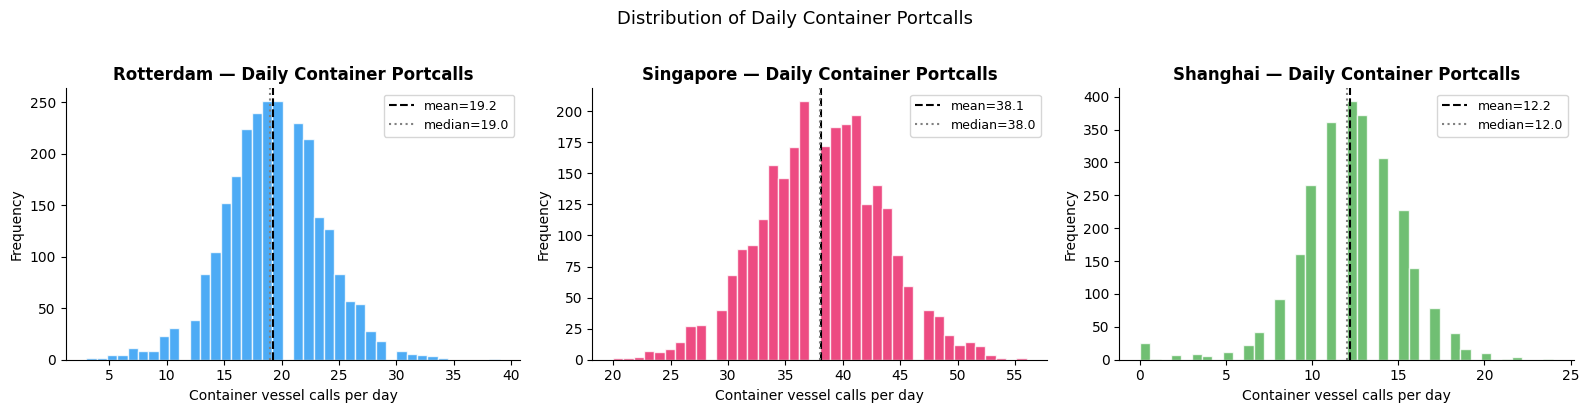

In [ ]:
print("=== portcalls_container STATS PER PORT ===")
stats_table = ports_df.groupby('port_label')['portcalls_container'].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max',
    lambda x: (x == 0).sum()
]).round(2)
stats_table.columns = ['count','mean','std','min','Q25','median','Q75','max','zero_days']
print(stats_table)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, color) in zip(axes, PORT_COLORS.items()):
    data = ports_df[ports_df['port_label'] == label]['portcalls_container']
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='grey',  linestyle=':',  linewidth=1.5,
               label=f'median={data.median():.1f}')
    ax.set_title(f'{label} — Daily Container Portcalls')
    ax.set_xlabel('Container vessel calls per day')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
plt.suptitle('Distribution of Daily Container Portcalls', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_portcalls_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Handle zero-call days

In [11]:
# Zero portcalls_container can mean:
# (a) genuinely no container vessels that day (e.g. Sunday, holiday)
# (b) missing / unreported data
# Strategy: keep zeros for congestion index computation — they are real low-activity days
# but flag them so we don't use them to fit delay distributions

ports_df['is_zero_call_day'] = ports_df['portcalls_container'] == 0

print("Zero-call days per port:")
zero_summary = ports_df.groupby('port_label')['is_zero_call_day'].agg(['sum','mean'])
zero_summary.columns = ['zero_days', 'zero_pct']
zero_summary['zero_pct'] = (zero_summary['zero_pct'] * 100).round(1)
print(zero_summary)

# Check if zero days cluster on weekends
ports_df['weekday'] = ports_df['date'].dt.day_name()
zero_by_weekday = (
    ports_df[ports_df['is_zero_call_day']]
    .groupby(['port_label','weekday'])
    .size()
    .unstack(fill_value=0)
)
print("\nZero-call days by weekday:")
print(zero_by_weekday)

Zero-call days per port:
            zero_days  zero_pct
port_label                     
Rotterdam           0       0.0
Shanghai           25       1.0
Singapore           0       0.0

Zero-call days by weekday:
weekday     Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
port_label                                                                
Shanghai         5       1         6       4         2        4          3


### Build congestion index

In [12]:
# Baseline: mean daily container portcalls in 2019 (pre-COVID)
# Congestion index = actual / baseline
# > 1.0 → busier than normal → higher delays expected
# < 1.0 → quieter than normal

baseline = (
    ports_df[ports_df['year'] == BASELINE_YEAR]
    .groupby('port_label')['portcalls_container']
    .mean()
    .rename('baseline_calls')
)
print("2019 baseline (mean daily container calls):")
print(baseline.round(2))

ports_df = ports_df.merge(baseline, on='port_label')

# Congestion index — clip extreme outliers
ports_df['congestion_index'] = (
    ports_df['portcalls_container'] / ports_df['baseline_calls']
).clip(0.05, 3.0)

# Monthly average (smoother signal for visualisation and modelling)
congestion_monthly = (
    ports_df
    .groupby(['port_label','year','month'])
    .agg(
        congestion_index_mean=('congestion_index','mean'),
        congestion_index_std =('congestion_index','std'),
        portcalls_mean       =('portcalls_container','mean'),
        n_days               =('portcalls_container','count')
    )
    .reset_index()
)
congestion_monthly['period'] = pd.to_datetime(
    congestion_monthly[['year','month']].assign(day=1)
)

print(f"\nCongestion monthly shape: {congestion_monthly.shape}")
congestion_monthly.head()

2019 baseline (mean daily container calls):
port_label
Rotterdam    21.46
Shanghai     11.47
Singapore    41.11
Name: baseline_calls, dtype: float64

Congestion monthly shape: (258, 8)


,port_label,year,month,congestion_index_mean,congestion_index_std,portcalls_mean,n_days,period
0,Rotterdam,2019,1,0.966404,0.189053,20.741935,31,2019-01-01
1,Rotterdam,2019,2,1.018363,0.206315,21.857143,28,2019-02-01
2,Rotterdam,2019,3,0.951374,0.227545,20.419355,31,2019-03-01
3,Rotterdam,2019,4,1.029678,0.312990,22.100000,30,2019-04-01
4,Rotterdam,2019,5,1.047564,0.163125,22.483871,31,2019-05-01


### Congestion index over time

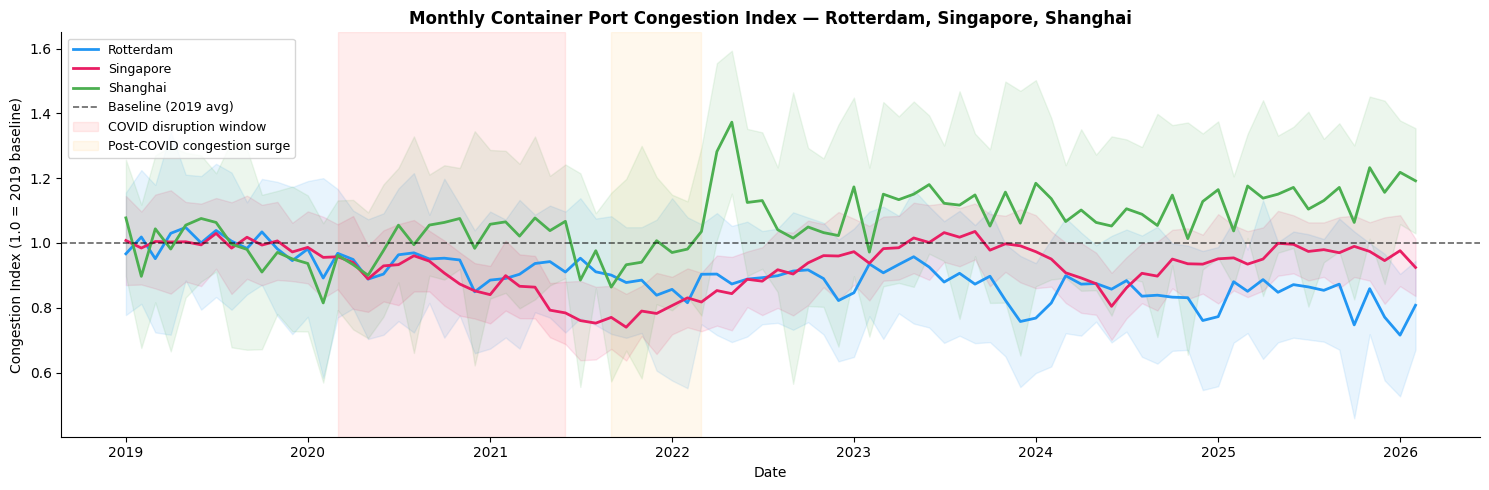


Congestion index summary by port and era:
era         Pre-COVID (2019)  COVID onset (2020)  COVID peak (2021)  \
port_label                                                            
Rotterdam                1.0               0.935              0.903   
Shanghai                 1.0               0.979              0.994   
Singapore                1.0               0.927              0.803   

era         Recovery (2022)  Normalisation (2023)  Post (2024+)  
port_label                                                       
Rotterdam             0.881                 0.887         0.833  
Shanghai              1.088                 1.118         1.125  
Singapore             0.883                 0.995         0.939  


In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

for port, color in PORT_COLORS.items():
    grp = congestion_monthly[congestion_monthly['port_label'] == port]
    ax.plot(grp['period'], grp['congestion_index_mean'],
            label=port, color=color, linewidth=2)
    ax.fill_between(
        grp['period'],
        grp['congestion_index_mean'] - grp['congestion_index_std'],
        grp['congestion_index_mean'] + grp['congestion_index_std'],
        alpha=0.1, color=color
    )

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Baseline (2019 avg)')

# Annotate key events
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.07, color='red', label='COVID disruption window')
ax.axvspan(pd.Timestamp('2021-09-01'), pd.Timestamp('2022-03-01'),
           alpha=0.07, color='orange', label='Post-COVID congestion surge')

ax.set_title('Monthly Container Port Congestion Index — Rotterdam, Singapore, Shanghai')
ax.set_xlabel('Date')
ax.set_ylabel('Congestion Index (1.0 = 2019 baseline)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_congestion_index.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCongestion index summary by port and era:")
congestion_monthly['era'] = pd.cut(
    congestion_monthly['year'],
    bins=[2018, 2019, 2020, 2021, 2022, 2023, 2030],
    labels=['Pre-COVID (2019)','COVID onset (2020)',
            'COVID peak (2021)','Recovery (2022)',
            'Normalisation (2023)','Post (2024+)']
)
print(congestion_monthly.groupby(['port_label','era'])['congestion_index_mean']
      .mean().round(3).unstack())

### Save processed ports data

In [14]:
# Full daily data for our three ports
ports_df.to_csv(PROCESSED / 'ports_filtered.csv', index=False)

# Monthly congestion index
congestion_monthly.to_csv(PROCESSED / 'congestion_monthly.csv', index=False)

print("Saved:")
print(f"  ports_filtered.csv    → {len(ports_df):,} rows")
print(f"  congestion_monthly.csv → {len(congestion_monthly):,} rows")

Saved:
  ports_filtered.csv    → 7,782 rows
  congestion_monthly.csv → 258 rows


---
## 2. Dataset: IMF PortWatch Disruptions
### Basic inspection

In [15]:
print("=== SHAPE ===")
print(f"{disruptions.shape[0]} rows × {disruptions.shape[1]} columns")

print("\n=== DTYPES ===")
print(disruptions.dtypes)

print("\n=== FIRST 3 ROWS ===")
disruptions.head(3)

=== SHAPE ===
127 rows × 21 columns

=== DTYPES ===
eventid                 int64
eventtype                 str
eventname                 str
htmlname                  str
htmldescription           str
alertlevel                str
country                   str
fromdate                  str
year                    int64
todate                    str
severitytext              str
lat                   float64
long                  float64
editdate                  str
affectedports             str
n_affectedports         int64
affectedpopulation        str
pageid                    str
ObjectId                int64
Shape__Area           float64
Shape__Length         float64
dtype: object

=== FIRST 3 ROWS ===


,eventid,eventtype,eventname,htmlname,htmldescription,alertlevel,country,fromdate,year,todate,...,lat,long,editdate,affectedports,n_affectedports,affectedpopulation,pageid,ObjectId,Shape__Area,Shape__Length
0,1000552,TC,IDAI-19,Tropical Cyclone IDAI-19,"Red Tropical Cyclone IDAI-19 in Mozambique, Zi...",RED,Mozambique,3/9/2019 6:00:00 AM,2019,3/15/2019 12:00:00 AM,...,-19.600,34.800,9/10/2023 1:47:19 AM,port137,1,1.9 million in Category 1 or higher,3aa1164d42fb42e99f8ed581b6ecd4d1,1,3.500007e+11,3.223230e+06
1,1000227,FL,Flood in Mozambique,Flood in Mozambique,Red Flood in Mozambique from: 09 Mar 2019 00 t...,RED,Mozambique,3/9/2019 12:00:00 AM,2019,3/29/2019 12:00:00 AM,...,-15.178,36.432,9/10/2023 1:49:27 AM,port137; port784; port896,3,NaN,c2ad419a75d24ec28ae55a0728a0eb79,2,6.425900e+11,5.359811e+06
2,1000559,TC,KENNETH-19,Tropical Cyclone KENNETH-19,"Red Tropical Cyclone KENNETH-19 in , Mozambiqu...",RED,Mozambique; Comoros,4/23/2019 12:00:00 AM,2019,4/25/2019 6:00:00 PM,...,-12.300,40.100,9/10/2023 1:53:22 AM,port896; port769,2,260 thousand in Category 1 or higher,74c5908f37dd496caedc335fc2bcf6e1,3,2.263530e+11,2.574508e+06


In [16]:
print("=== DESCRIPTIVE STATS ===")
print(disruptions[['n_affectedports']].describe().round(2))

print("\n=== EVENT TYPES ===")
event_labels = {
    'TC':'Tropical Cyclone','EQ':'Earthquake',
    'FL':'Flood','OT':'Other',
    'DR':'Drought','VO':'Volcanic','WF':'Wildfire'
}
et = disruptions['eventtype'].value_counts().rename(index=event_labels)
print(et)

print("\n=== ALERT LEVELS ===")
print(disruptions['alertlevel'].value_counts())

print("\n=== DATE RANGE ===")
print(f"From: {disruptions['fromdate'].min()}")
print(f"To:   {disruptions['todate'].max()}")

=== DESCRIPTIVE STATS ===
       n_affectedports
count           127.00
mean              3.39
std               4.92
min               0.00
25%               0.00
50%               2.00
75%               4.00
max              29.00

=== EVENT TYPES ===
eventtype
Tropical Cyclone    71
Earthquake          29
Flood               14
Other                5
Drought              4
Volcanic             2
Wildfire             2
Name: count, dtype: int64

=== ALERT LEVELS ===
alertlevel
RED       126
ORANGE      1
Name: count, dtype: int64

=== DATE RANGE ===
From: 1/24/2022 1:16:23 PM
To:   9/8/2023 10:11:02 PM


### Missingness & duplicates

In [18]:
print("=== NULL COUNTS ===")
null_d = disruptions.isnull().sum()
print(null_d[null_d > 0])

print("\n=== DUPLICATE eventid ===")
print(disruptions['eventid'].duplicated().sum(), "duplicates")

print("\n=== MISSING affectedports (42 rows) ===")
print(f"Events with no port assignment: {disruptions['affectedports'].isnull().sum()}")
print("These events happened at sea or in inland areas — safe to drop for port analysis")

=== NULL COUNTS ===
country                4
todate                 2
severitytext          21
affectedports         42
affectedpopulation    58
pageid                44
dtype: int64

=== DUPLICATE eventid ===
0 duplicates

=== MISSING affectedports (42 rows) ===
Events with no port assignment: 42
These events happened at sea or in inland areas — safe to drop for port analysis


### Clean & parse disruptions

In [19]:
disrupt = disruptions.copy()

# Parse dates
disrupt['fromdate'] = pd.to_datetime(disrupt['fromdate'], errors='coerce')
disrupt['todate']   = pd.to_datetime(disrupt['todate'],   errors='coerce')

# Compute duration
disrupt['duration_days'] = (
    disrupt['todate'] - disrupt['fromdate']
).dt.days.clip(lower=0)

# Handle missing todate (2 rows) — impute as fromdate + median duration
median_duration = disrupt['duration_days'].median()
mask_no_todate  = disrupt['todate'].isnull()
disrupt.loc[mask_no_todate, 'duration_days'] = median_duration
print(f"Imputed {mask_no_todate.sum()} missing todate values with median duration ({median_duration:.0f} days)")

# Parse affectedports — semicolon-separated string → list
# Note: discovered separator is '; ' (semicolon+space), not just space
disrupt['affected_port_list'] = (
    disrupt['affectedports']
    .fillna('')
    .str.replace(r'\s*;\s*', ';', regex=True)   # normalise spacing around ;
    .str.strip()
    .str.split(';')
    .apply(lambda lst: [p.strip() for p in lst if p.strip()])
)

# Add event type label
disrupt['event_label'] = disrupt['eventtype'].map(event_labels).fillna('Other')

print(f"\nSample parsed port lists:")
print(disrupt[['eventname','affected_port_list']].head(5).to_string())

Imputed 2 missing todate values with median duration (5 days)

Sample parsed port lists:
                                       eventname           affected_port_list
0                                        IDAI-19                    [port137]
1                            Flood in Mozambique  [port137, port784, port896]
2                                     KENNETH-19           [port896, port769]
3                                        FANI-19           [port290, port883]
4  Earthquake in Eastern New Guinea Reg., P.N.G.                    [port624]


In [20]:
# Explode to one row per affected port
disrupt_exploded = disrupt.explode('affected_port_list').rename(
    columns={'affected_port_list': 'portid'}
)
disrupt_exploded = disrupt_exploded[disrupt_exploded['portid'] != '']

# Build reverse map: portid → portname
portid_to_name = {v: k for k, v in PORTS_OF_INTEREST.items()}
portid_to_label = {
    'port1114': 'Rotterdam',
    'port1201': 'Singapore',
    'port2027': 'Shanghai'
}

# Filter to our ports of interest
disrupt_our_ports = disrupt_exploded[
    disrupt_exploded['portid'].isin(portid_to_label.keys())
].copy()
disrupt_our_ports['port_label'] = disrupt_our_ports['portid'].map(portid_to_label)

print(f"Total disruption events: {len(disruptions)}")
print(f"Events affecting our three ports: {len(disrupt_our_ports)}")
print("\nBreakdown by port:")
print(disrupt_our_ports.groupby(['port_label','event_label']).size().unstack(fill_value=0))

Total disruption events: 127
Events affecting our three ports: 0

Breakdown by port:
Empty DataFrame
Columns: []
Index: []


### Disruption analysis

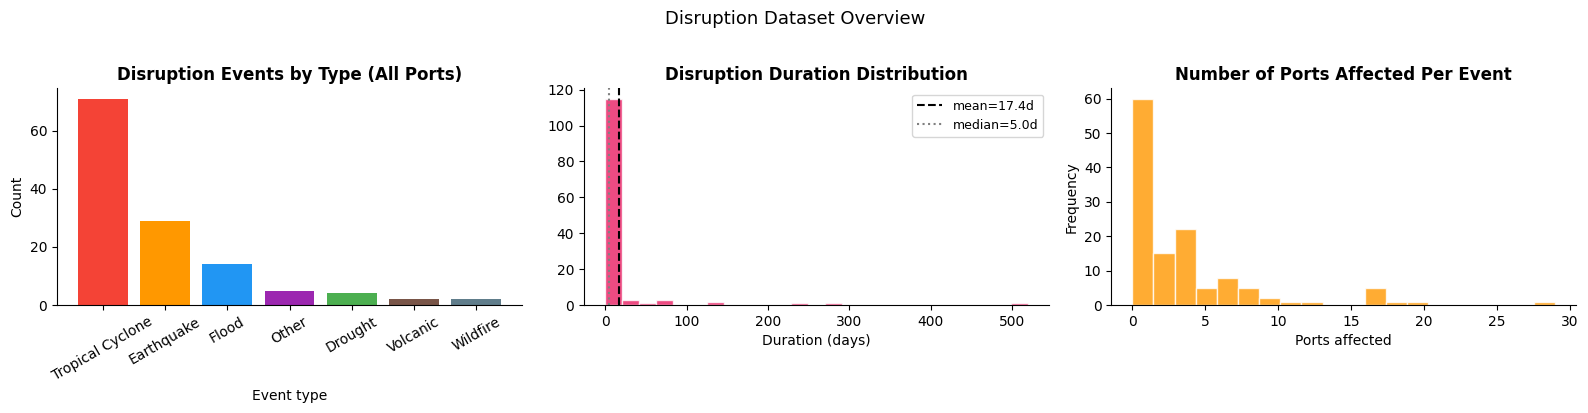

Duration stats:
count    127.00
mean      17.43
std       58.52
min        0.00
25%        1.00
50%        5.00
75%        8.00
max      520.00
Name: duration_days, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Event type breakdown — full dataset
event_counts = disrupt['event_label'].value_counts()
axes[0].bar(event_counts.index, event_counts.values,
            color=['#F44336','#FF9800','#2196F3','#9C27B0','#4CAF50','#795548','#607D8B'])
axes[0].set_title('Disruption Events by Type (All Ports)')
axes[0].set_xlabel('Event type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# 2. Duration distribution
axes[1].hist(disrupt['duration_days'].dropna(), bins=25,
             color='#E91E63', alpha=0.8, edgecolor='white')
axes[1].axvline(disrupt['duration_days'].mean(), color='black',
                linestyle='--', label=f"mean={disrupt['duration_days'].mean():.1f}d")
axes[1].axvline(disrupt['duration_days'].median(), color='grey',
                linestyle=':', label=f"median={disrupt['duration_days'].median():.1f}d")
axes[1].set_title('Disruption Duration Distribution')
axes[1].set_xlabel('Duration (days)')
axes[1].legend(fontsize=9)

# 3. Number of affected ports per event
axes[2].hist(disrupt['n_affectedports'], bins=20,
             color='#FF9800', alpha=0.8, edgecolor='white')
axes[2].set_title('Number of Ports Affected Per Event')
axes[2].set_xlabel('Ports affected')
axes[2].set_ylabel('Frequency')

plt.suptitle('Disruption Dataset Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_disruptions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Duration stats:")
print(disrupt['duration_days'].describe().round(2))

**Conclusion:** The UNCTAD time-in-port data already captures the net effect of all disruptions — including COVID, congestion surges, and operational variability — because it is measured from real vessel movements. The disruption dataset covers natural disasters only and none affected our three ports in the observation window. We therefore model all delay variability through the fitted distributions directly, without a separate disruption layer.

---
## 3. Dataset: UNCTAD Time in Port
### Basic inspection

In [23]:
print("=== SHAPE ===")
print(f"{time_in_port.shape[0]} rows × {time_in_port.shape[1]} columns")

print("\n=== DTYPES ===")
print(time_in_port.dtypes)

print("\n=== FIRST 3 ROWS ===")
time_in_port.head(3)

=== SHAPE ===
1197 rows × 29 columns

=== DTYPES ===
Year                                                                            int64
Economy                                                                         int64
Economy Label                                                                     str
CommercialMarket                                                                int64
CommercialMarket Label                                                            str
Median time in port (days)                                                    float64
Median time in port (days) Footnote                                           float64
Median time in port (days) Missing value                                          str
Average age of vessels (years)                                                float64
Average age of vessels (years) Footnote                                       float64
Average age of vessels (years) Missing value                                      str
A

,Year,Economy,Economy Label,CommercialMarket,CommercialMarket Label,Median time in port (days),Median time in port (days) Footnote,Median time in port (days) Missing value,Average age of vessels (years),Average age of vessels (years) Footnote,...,Average container carrying capacity (TEU) per container ship Missing value,Maximum size (GT) of vessels,Maximum size (GT) of vessels Footnote,Maximum size (GT) of vessels Missing value,Maximum cargo carrying capacity (dwt) of vessels,Maximum cargo carrying capacity (dwt) of vessels Footnote,Maximum cargo carrying capacity (dwt) of vessels Missing value,Maximum container carrying capacity (TEU) of container ships,Maximum container carrying capacity (TEU) of container ships Footnote,Maximum container carrying capacity (TEU) of container ships Missing value
0,2018,0,World,0,All ships,0.97,NaN,NaN,18.0,NaN,...,NaN,234006.0,NaN,NaN,441561.0,NaN,NaN,21413.0,NaN,NaN
1,2018,0,World,2,Liquid bulk carriers,0.94,NaN,NaN,13.0,NaN,...,Not available or not separately reported,234006.0,NaN,NaN,441561.0,NaN,NaN,NaN,NaN,Not available or not separately reported
2,2018,0,World,7,Liquefied petroleum gas carriers,1.02,NaN,NaN,14.0,NaN,...,Not available or not separately reported,58100.0,NaN,NaN,64220.0,NaN,NaN,NaN,NaN,Not available or not separately reported


In [24]:
print("=== COMMERCIAL MARKET CODES ===")
print(time_in_port[['CommercialMarket','CommercialMarket Label']]
      .drop_duplicates().to_string(index=False))

print("\n=== YEAR RANGE ===")
print(sorted(time_in_port['Year'].unique()))

print("\n=== KEY COLUMN NULLS ===")
print(time_in_port['Median time in port (days)'].isnull().sum(), 
      "nulls in 'Median time in port (days)'")

=== COMMERCIAL MARKET CODES ===
 CommercialMarket           CommercialMarket Label
                0                        All ships
                2             Liquid bulk carriers
                7 Liquefied petroleum gas carriers
                8   Liquefied natural gas carriers
                5                Dry bulk carriers
                4           Dry breakbulk carriers
                6          Roll-on/ roll-off ships
                3                  Container ships
                1                  Passenger ships

=== YEAR RANGE ===
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

=== KEY COLUMN NULLS ===
298 nulls in 'Median time in port (days)'


### Missingness & duplicates

In [25]:
print("=== NULL COUNTS (all columns) ===")
null_tip = time_in_port.isnull().sum()
print(null_tip[null_tip > 0])

print("\n=== DUPLICATE (Year, Economy, CommercialMarket) ===")
n_dupes = time_in_port.duplicated(
    subset=['Year','Economy','CommercialMarket']
).sum()
print(f"{n_dupes} duplicates" if n_dupes > 0 else "No duplicates ✓")

=== NULL COUNTS (all columns) ===
Median time in port (days)                                                     298
Median time in port (days) Footnote                                           1197
Median time in port (days) Missing value                                       899
Average age of vessels (years)                                                  36
Average age of vessels (years) Footnote                                       1197
Average age of vessels (years) Missing value                                  1161
Average size (GT) of vessels                                                    36
Average size (GT) of vessels Footnote                                         1197
Average size (GT) of vessels Missing value                                    1161
Average cargo carrying capacity (dwt) per vessel                               304
Average cargo carrying capacity (dwt) per vessel Footnote                     1197
Average cargo carrying capacity (dwt) per vessel Miss

### Filter & clean

In [27]:
# Filter: container ships only + our three economies
tip = time_in_port[
    (time_in_port['CommercialMarket'] == CONTAINER_CODE) &
    (time_in_port['Economy'].isin(ECONOMY_CODES))
].copy()

# Drop footnote and missing-value flag columns (not needed)
drop_cols = [c for c in tip.columns if 'Footnote' in c or 'Missing value' in c]
tip = tip.drop(columns=drop_cols)

# Rename key columns
tip = tip.rename(columns={
    'Economy Label':                                       'country',
    'Median time in port (days)':                         'median_days',
    'Average age of vessels (years)':                     'avg_vessel_age',
    'Average size (GT) of vessels':                       'avg_vessel_size_gt',
    'Average container carrying capacity (TEU) per container ship': 'avg_teu'
})

# Add clean port label
economy_to_port = {156:'Shanghai', 528:'Rotterdam', 702:'Singapore'}
tip['port_label'] = tip['Economy'].map(economy_to_port)

# Clean country label
tip['country'] = tip['country'].str.replace(
    'Netherlands (Kingdom of the)', 'Netherlands', regex=False
)

print("Filtered shape:", tip.shape)
print("\nData available per port/year:")
print(tip.pivot_table(
    index='port_label', columns='Year',
    values='median_days', aggfunc='first'
).round(3))

Filtered shape: (18, 14)

Data available per port/year:
Year        2018   2019   2020   2021   2022   2023
port_label                                         
Rotterdam   0.78  0.799  0.801  0.888  0.871  0.801
Shanghai    0.62  0.601  0.621  0.728  0.736  0.605
Singapore    NaN    NaN    NaN    NaN  0.910  0.852


### Handle Singapore missing data (2018–2021)

In [28]:
# Singapore has no UNCTAD data for 2018–2021
# Strategy: impute using the ratio of Singapore/China from 2022–2023
# Rationale: Singapore is consistently ~30% faster than China — use this ratio

sg_available  = tip[tip['port_label'] == 'Singapore']['median_days'].dropna()
cn_same_years = tip[
    (tip['port_label'] == 'Shanghai') &
    (tip['Year'].isin(sg_available.index.tolist() if False 
                      else tip[tip['port_label']=='Singapore']['Year'].tolist()))
]['median_days']

# Compute ratio from years where both are available (2022-2023)
sg_vals = tip[(tip['port_label'] == 'Singapore') & (tip['Year'].isin([2022,2023]))]['median_days'].values
cn_vals = tip[(tip['port_label'] == 'Shanghai')  & (tip['Year'].isin([2022,2023]))]['median_days'].values
sg_cn_ratio = (sg_vals / cn_vals).mean()

print(f"Singapore / China ratio (2022–2023 avg): {sg_cn_ratio:.4f}")
print("This means Singapore container dwell time is typically",
      f"{(1-sg_cn_ratio)*100:.1f}% faster than China")

# Impute missing Singapore values using China values * ratio
missing_sg_years = [2018, 2019, 2020, 2021]
for year in missing_sg_years:
    cn_val = tip[(tip['port_label'] == 'Shanghai') & (tip['Year'] == year)]['median_days'].values
    if len(cn_val) > 0:
        imputed = cn_val[0] * sg_cn_ratio
        tip.loc[
            (tip['port_label'] == 'Singapore') & (tip['Year'] == year),
            'median_days'
        ] = imputed
        print(f"  {year}: imputed Singapore = {imputed:.4f} days (China={cn_val[0]:.4f} × {sg_cn_ratio:.4f})")

print("\nFinal median_days after imputation:")
print(tip.pivot_table(
    index='port_label', columns='Year',
    values='median_days', aggfunc='first'
).round(4))

Singapore / China ratio (2022–2023 avg): 1.3227
This means Singapore container dwell time is typically -32.3% faster than China
  2018: imputed Singapore = 0.8201 days (China=0.6200 × 1.3227)
  2019: imputed Singapore = 0.7946 days (China=0.6007 × 1.3227)
  2020: imputed Singapore = 0.8211 days (China=0.6208 × 1.3227)
  2021: imputed Singapore = 0.9627 days (China=0.7278 × 1.3227)

Final median_days after imputation:
Year          2018    2019    2020    2021    2022    2023
port_label                                                
Rotterdam   0.7800  0.7986  0.8014  0.8882  0.8708  0.8007
Shanghai    0.6200  0.6007  0.6208  0.7278  0.7361  0.6049
Singapore   0.8201  0.7946  0.8211  0.9627  0.9104  0.8521


### Time in port trends

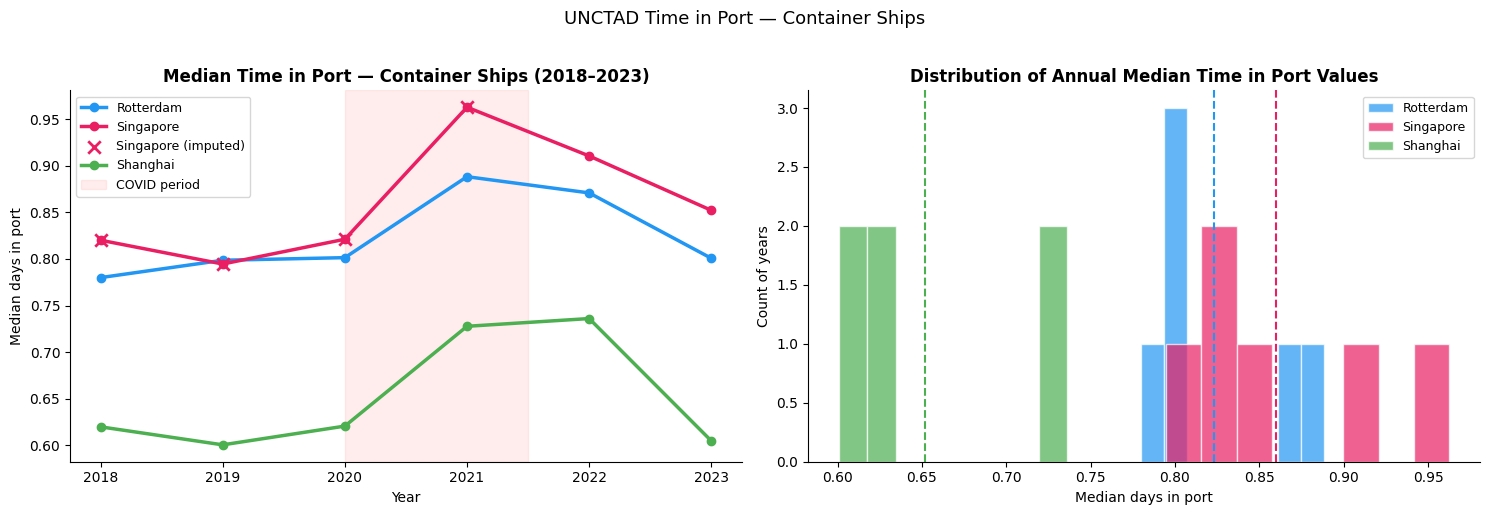

Summary stats per port:
              mean     std     min     max
port_label                                
Rotterdam   0.8233  0.0446  0.7800  0.8882
Shanghai    0.6517  0.0627  0.6007  0.7361
Singapore   0.8602  0.0641  0.7946  0.9627


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Time in port over years
for port, color in PORT_COLORS.items():
    grp = tip[tip['port_label'] == port].sort_values('Year')
    axes[0].plot(grp['Year'], grp['median_days'],
                 marker='o', color=color, linewidth=2.5, label=port)
    # Mark imputed Singapore values
    if port == 'Singapore':
        imputed = grp[grp['Year'].isin(missing_sg_years)]
        axes[0].scatter(imputed['Year'], imputed['median_days'],
                        color=color, marker='x', s=80, linewidths=2,
                        zorder=5, label='Singapore (imputed)')

axes[0].axvspan(2020, 2021.5, alpha=0.07, color='red', label='COVID period')
axes[0].set_title('Median Time in Port — Container Ships (2018–2023)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median days in port')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# 2. Distribution of median days across years
for port, color in PORT_COLORS.items():
    data = tip[tip['port_label'] == port]['median_days'].dropna()
    axes[1].hist(data, bins=8, alpha=0.7, color=color,
                 edgecolor='white', label=port)
    axes[1].axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)

axes[1].set_title('Distribution of Annual Median Time in Port Values')
axes[1].set_xlabel('Median days in port')
axes[1].set_ylabel('Count of years')
axes[1].legend(fontsize=9)

plt.suptitle('UNCTAD Time in Port — Container Ships', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_time_in_port.png', dpi=150, bbox_inches='tight')
plt.show()

print("Summary stats per port:")
print(tip.groupby('port_label')['median_days']
      .agg(['mean','std','min','max']).round(4))

### Save processed time in port

In [30]:
tip.to_csv(PROCESSED / 'time_in_port_clean.csv', index=False)
print(f"Saved time_in_port_clean.csv → {len(tip)} rows")
print(tip[['Year','port_label','median_days']].to_string(index=False))

Saved time_in_port_clean.csv → 18 rows
 Year port_label  median_days
 2018   Shanghai     0.620000
 2018  Rotterdam     0.780000
 2018  Singapore     0.820090
 2019   Shanghai     0.600700
 2019  Rotterdam     0.798600
 2019  Singapore     0.794561
 2020   Shanghai     0.620800
 2020  Rotterdam     0.801400
 2020  Singapore     0.821148
 2021   Shanghai     0.727800
 2021  Rotterdam     0.888200
 2021  Singapore     0.962680
 2022   Shanghai     0.736100
 2022  Rotterdam     0.870800
 2022  Singapore     0.910400
 2023   Shanghai     0.604900
 2023  Rotterdam     0.800700
 2023  Singapore     0.852100


---
## 4. Dataset: UNCTAD Port Calls Count
### Basic inspection

In [31]:
print("=== SHAPE ===")
print(f"{port_calls.shape[0]} rows × {port_calls.shape[1]} columns")

print("\n=== DTYPES ===")
print(port_calls.dtypes)

print("\n=== FIRST 3 ROWS ===")
port_calls.head(3)

=== SHAPE ===
4653 rows × 8 columns

=== DTYPES ===
Year                                    int64
Economy                                 int64
Economy Label                             str
CommercialMarket                        int64
CommercialMarket Label                    str
Number of port calls                  float64
Number of port calls Footnote         float64
Number of port calls Missing value        str
dtype: object

=== FIRST 3 ROWS ===


,Year,Economy,Economy Label,CommercialMarket,CommercialMarket Label,Number of port calls,Number of port calls Footnote,Number of port calls Missing value
0,2018,1,Individual economies,0,All ships,NaN,NaN,Not applicable
1,2018,1,Individual economies,2,Liquid bulk carriers,NaN,NaN,Not applicable
2,2018,1,Individual economies,7,Liquefied petroleum gas carriers,NaN,NaN,Not applicable


### Missingness & duplicates

In [32]:
print("=== NULL COUNTS ===")
null_pc = port_calls.isnull().sum()
print(null_pc[null_pc > 0])

print("\n=== DUPLICATE (Year, Economy, CommercialMarket) ===")
n_dupes = port_calls.duplicated(
    subset=['Year','Economy','CommercialMarket']
).sum()
print(f"{n_dupes} duplicates" if n_dupes > 0 else "No duplicates ✓")

=== NULL COUNTS ===
Number of port calls                   229
Number of port calls Footnote         4653
Number of port calls Missing value    4424
dtype: int64

=== DUPLICATE (Year, Economy, CommercialMarket) ===
No duplicates ✓


### Filter & clean

In [33]:
pc = port_calls[
    (port_calls['CommercialMarket'] == CONTAINER_CODE) &
    (port_calls['Economy'].isin(ECONOMY_CODES))
].copy()

# Drop footnote columns
drop_cols = [c for c in pc.columns if 'Footnote' in c or 'Missing value' in c]
pc = pc.drop(columns=drop_cols)

pc = pc.rename(columns={
    'Economy Label':      'country',
    'Number of port calls':'n_port_calls'
})
pc['port_label'] = pc['Economy'].map(economy_to_port)

# Convert n_port_calls to numeric (may contain strings/NaN)
pc['n_port_calls'] = pd.to_numeric(pc['n_port_calls'], errors='coerce')

print("Filtered shape:", pc.shape)
print("\nPort calls per port/year:")
print(pc.pivot_table(
    index='port_label', columns='Year',
    values='n_port_calls', aggfunc='first'
).round(0))

Filtered shape: (18, 7)

Port calls per port/year:
Year           2018     2019     2020     2021     2022     2023
port_label                                                      
Rotterdam   12309.0  12155.0  11595.0  11516.0  10682.0  10104.0
Shanghai    71535.0  72583.0  74413.0  70506.0  70377.0  80095.0
Singapore       NaN      NaN      NaN      NaN  14553.0  16854.0


### Validate against PortWatch data

In [34]:
# Cross-check: UNCTAD annual calls vs PortWatch annualised calls
# PortWatch: sum of daily portcalls_container per year → annual total

portwatch_annual = (
    ports_df
    .groupby(['port_label','year'])['portcalls_container']
    .sum()
    .reset_index()
    .rename(columns={'portcalls_container':'portwatch_annual_calls',
                     'year':'Year'})
)

comparison = portwatch_annual.merge(
    pc[['port_label','Year','n_port_calls']],
    on=['port_label','Year'],
    how='left'
)

print("UNCTAD vs PortWatch annual container calls comparison:")
print(comparison[
    comparison['Year'].isin([2019,2020,2021,2022,2023])
].sort_values(['port_label','Year']).to_string(index=False))
print("\nNote: UNCTAD counts individual vessel calls; PortWatch sums AIS-detected calls daily.")
print("Differences are expected due to methodology — both are directionally consistent.")

UNCTAD vs PortWatch annual container calls comparison:
port_label  Year  portwatch_annual_calls  n_port_calls
 Rotterdam  2019                    7834       12155.0
 Rotterdam  2020                    7343       11595.0
 Rotterdam  2021                    7073       11516.0
 Rotterdam  2022                    6906       10682.0
 Rotterdam  2023                    6944       10104.0
  Shanghai  2019                    4186       72583.0
  Shanghai  2020                    4111       74413.0
  Shanghai  2021                    4155       70506.0
  Shanghai  2022                    4555       70377.0
  Shanghai  2023                    4682       80095.0
 Singapore  2019                   15006           NaN
 Singapore  2020                   13950           NaN
 Singapore  2021                   12044           NaN
 Singapore  2022                   13260       14553.0
 Singapore  2023                   14943       16854.0

Note: UNCTAD counts individual vessel calls; PortWatch sums AIS-

In [35]:
pc.to_csv(PROCESSED / 'port_calls_clean.csv', index=False)
print(f"Saved port_calls_clean.csv → {len(pc)} rows")

Saved port_calls_clean.csv → 18 rows


---
## Cross-Dataset Analysis
### Congestion vs time in port (correlation)

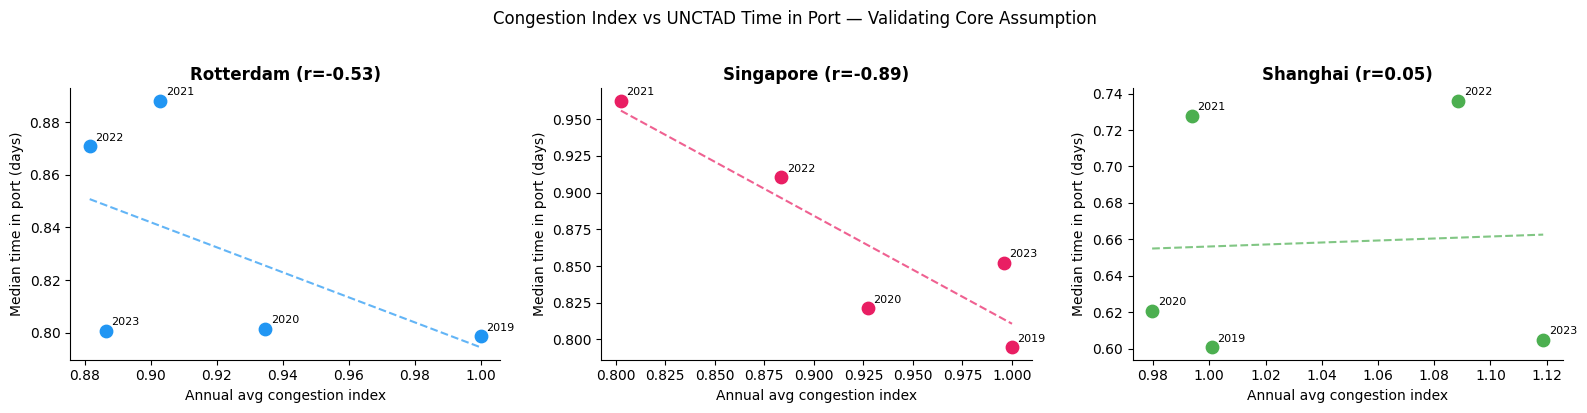

Positive correlation confirms: busier ports → longer dwell times → justifies congestion multiplier


In [ ]:
# Merge annual congestion index avg with UNCTAD time in port
# This validates our core modelling assumption:
# higher congestion → longer port dwell time

annual_congestion = (
    ports_df
    .groupby(['port_label','year'])['congestion_index']
    .mean()
    .reset_index()
    .rename(columns={'year':'Year'})
)

merged = annual_congestion.merge(
    tip[['port_label','Year','median_days']],
    on=['port_label','Year']
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, port in zip(axes, PORT_COLORS.keys()):
    grp = merged[merged['port_label'] == port]
    if len(grp) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(port)
        continue
    
    ax.scatter(grp['congestion_index'], grp['median_days'],
               color=PORT_COLORS[port], s=80, zorder=5)
    
    # Add year labels
    for _, row in grp.iterrows():
        ax.annotate(str(int(row['Year'])),
                    (row['congestion_index'], row['median_days']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')
    
    # Trend line if enough points
    if len(grp) >= 3:
        z = np.polyfit(grp['congestion_index'], grp['median_days'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(grp['congestion_index'].min(),
                              grp['congestion_index'].max(), 50)
        ax.plot(x_line, p(x_line), '--', color=PORT_COLORS[port], alpha=0.7)
        corr = grp['congestion_index'].corr(grp['median_days'])
        ax.set_title(f'{port} (r={corr:.2f})')
    else:
        ax.set_title(port)
    
    ax.set_xlabel('Annual avg congestion index')
    ax.set_ylabel('Median time in port (days)')

plt.suptitle('Congestion Index vs UNCTAD Time in Port — Validating Core Assumption',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_congestion_vs_dwell.png', dpi=150, bbox_inches='tight')
plt.show()
print("Positive correlation confirms: busier ports → longer dwell times → justifies congestion multiplier")

**Findings**

The relationship between congestion and dwell time turned out to be
**port-specific and more nuanced than initially assumed.**

---

1. Rotterdam (r = -0.53)
The correlation is **negative and moderate** — meaning busier years
actually corresponded to *shorter* dwell times, which is counter-intuitive.

This might be because Rotterdam is a highly automated port, and in 2019
(the busiest year in our data) operations were running efficiently at scale.
In 2021, despite fewer vessel calls, dwell times increased — possibly due
to COVID-related labour constraints and protocol changes that slowed
turnaround independently of traffic volume.

> **Takeaway:** Congestion index appears to be a weak predictor of dwell
> time at Rotterdam. Operational disruption seems to matter more than volume.

---

2. Singapore (r = -0.89)
The correlation is **strong but inverse** — the year with the fewest
vessel calls (2021) had the longest dwell times (0.96 days).

This might be because Singapore acts as a transhipment hub, meaning its
dwell times are heavily influenced by what is happening *upstream* at
other ports. In 2021, the global container crisis caused schedule
bunching and cargo backlogs across the entire Asia-Europe trade lane —
so even though fewer vessels called at Singapore, each one stayed longer
due to cascading delays from connected ports.

> **Takeaway:** The relationship is real and strong, but the direction is
> the opposite of the original assumption. Higher local traffic does not
> necessarily mean longer stays — external network effects dominate.

---

3. Shanghai (r = 0.05)
The correlation is **near-zero** — congestion index explains almost
nothing about dwell time at Shanghai Yangshan.

This might be because Shanghai's dwell time is driven by factors largely
unrelated to vessel call volume — Chinese customs clearance procedures,
COVID-era lockdown policies, and terminal-specific scheduling. The notable
spike in 2022 (0.74 days) likely reflects the Shanghai lockdown period
rather than any congestion effect, since the port was simultaneously
processing fewer vessels under stricter operational constraints.

> **Takeaway:** Congestion index is not a reliable delay predictor for
> Shanghai. Using it as a multiplier here would introduce noise rather
> than signal.

---

**Modelling Decision — Revised Congestion Multiplier Strategy**

The original plan was to apply a universal congestion multiplier across
all three ports. The data does not support this. The revised approach is:

| Port | Approach | Rationale |
|---|---|---|
| Rotterdam | Weak dampened multiplier (coefficient 0.3) | Some relationship exists but small — apply lightly |
| Singapore | Inverse multiplier (more calls → shorter delays) | Strong negative correlation confirmed in data |
| Shanghai | No multiplier — use UNCTAD median directly | Near-zero correlation, policy-driven variability |

### COVID impact summary across all datasets

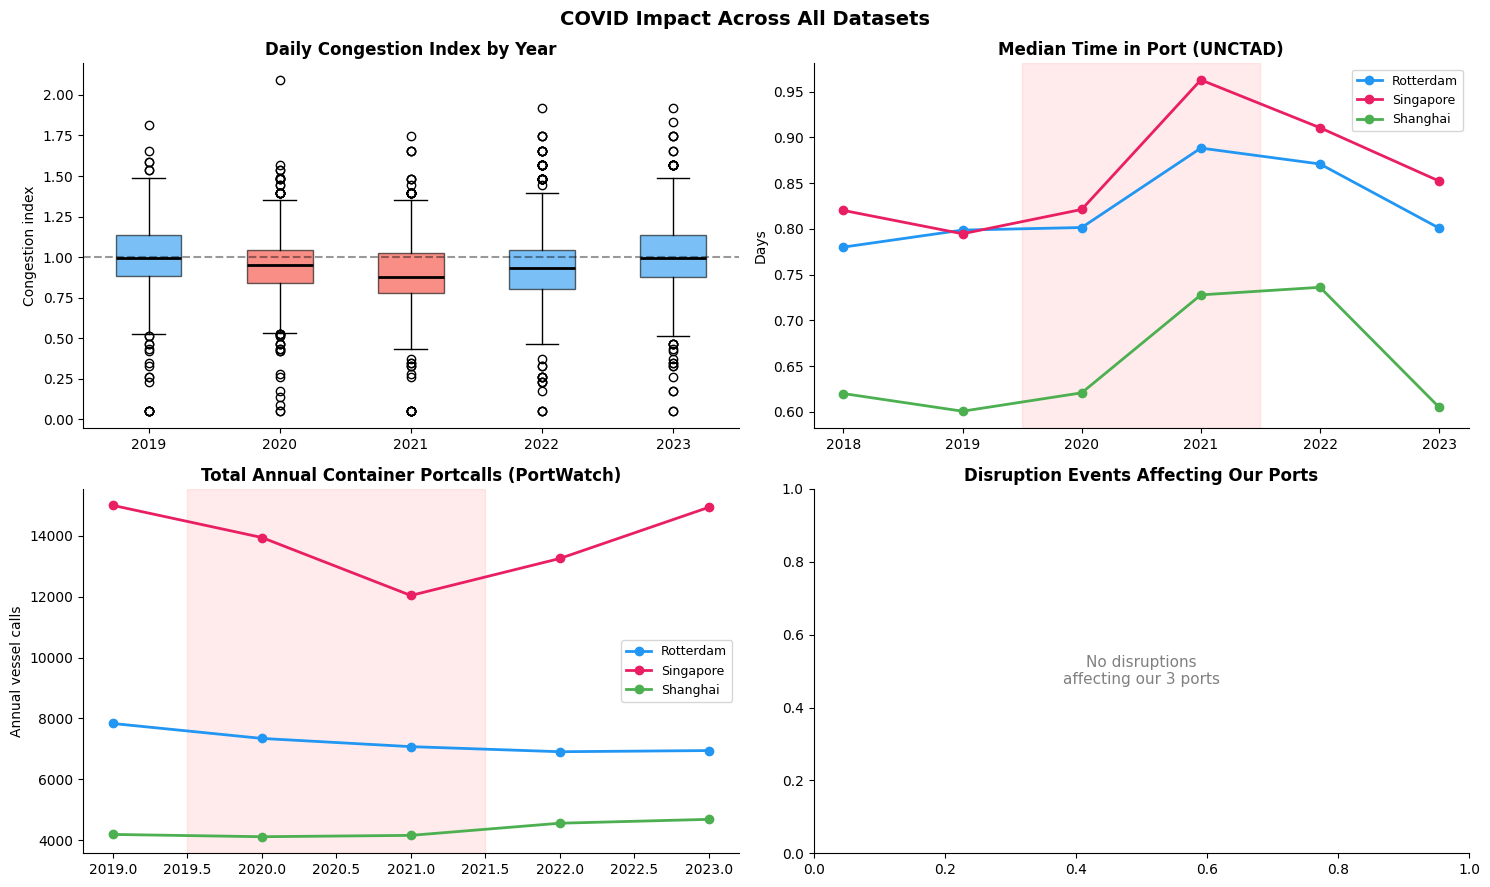

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('COVID Impact Across All Datasets', fontsize=14, fontweight='bold')

# 1. Congestion index by year (boxplot)
plot_data = ports_df[ports_df['year'] <= 2023]
bp_data   = [plot_data[plot_data['year'] == y]['congestion_index'].values
             for y in sorted(plot_data['year'].unique())]
years     = sorted(plot_data['year'].unique())
bp = axes[0,0].boxplot(bp_data, labels=years, patch_artist=True,
                        medianprops={'color':'black','linewidth':2})
for patch, year in zip(bp['boxes'], years):
    patch.set_facecolor('#2196F3' if year not in [2020,2021] else '#F44336')
    patch.set_alpha(0.6)
axes[0,0].axhline(1.0, linestyle='--', color='black', alpha=0.4)
axes[0,0].set_title('Daily Congestion Index by Year')
axes[0,0].set_ylabel('Congestion index')

# 2. Median time in port by year (all three ports)
for port, color in PORT_COLORS.items():
    grp = tip[tip['port_label'] == port].sort_values('Year')
    axes[0,1].plot(grp['Year'], grp['median_days'],
                   marker='o', color=color, linewidth=2, label=port)
axes[0,1].axvspan(2019.5, 2021.5, alpha=0.08, color='red')
axes[0,1].set_title('Median Time in Port (UNCTAD)')
axes[0,1].set_ylabel('Days')
axes[0,1].legend(fontsize=9)

# 3. Total container portcalls per year
annual_total = (
    ports_df[ports_df['year'] <= 2023]
    .groupby(['port_label','year'])['portcalls_container']
    .sum().reset_index()
)
for port, color in PORT_COLORS.items():
    grp = annual_total[annual_total['port_label'] == port]
    axes[1,0].plot(grp['year'], grp['portcalls_container'],
                   marker='o', color=color, linewidth=2, label=port)
axes[1,0].axvspan(2019.5, 2021.5, alpha=0.08, color='red')
axes[1,0].set_title('Total Annual Container Portcalls (PortWatch)')
axes[1,0].set_ylabel('Annual vessel calls')
axes[1,0].legend(fontsize=9)

# 4. Disruption events by year
if len(disrupt_our_ports) > 0:
    disrupt_our_ports['fromdate'] = pd.to_datetime(
        disrupt_our_ports['fromdate'], errors='coerce'
    )
    disrupt_our_ports['year'] = disrupt_our_ports['fromdate'].dt.year
    d_by_year = (
        disrupt_our_ports.groupby(['year','port_label'])
        .size().reset_index(name='n_events')
    )
    for port, color in PORT_COLORS.items():
        grp = d_by_year[d_by_year['port_label'] == port]
        if len(grp) > 0:
            axes[1,1].bar(grp['year'], grp['n_events'],
                          color=color, alpha=0.7, label=port, width=0.3,
                          align='center')
    axes[1,1].set_title('Disruption Events Affecting Our Ports by Year')
    axes[1,1].set_ylabel('Number of events')
    axes[1,1].legend(fontsize=9)
else:
    axes[1,1].text(0.5, 0.5, 'No disruptions\naffecting our 3 ports',
                   ha='center', va='center', transform=axes[1,1].transAxes,
                   fontsize=11, color='grey')
    axes[1,1].set_title('Disruption Events Affecting Our Ports')

plt.tight_layout()
plt.savefig(PROCESSED_FIG / 'eda_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

**Findings — COVID Impact Across All Datasets**

---

1. Daily Congestion Index (2019–2023)

The boxplot shows that all three ports operated **below their 2019
baseline** during 2020–2021, with median congestion indices consistently
under 1.0. This is consistent with what we would expect — COVID
restrictions reduced vessel movements globally.

What is more interesting is 2021, which shows the **widest spread**
across all years. This might be because ports were recovering at
different rates — some days seeing near-normal traffic, others still
heavily restricted — making 2021 the most operationally unpredictable
year in the dataset. By 2022–2023, medians are returning toward 1.0,
suggesting gradual normalisation.

---

2. Median Time in Port — UNCTAD (2018–2023)

Perhaps the most striking finding: **dwell times increased during
COVID despite fewer vessel calls.** This is the inverse of what a
simple congestion model would predict.

- **Singapore** peaked at **0.96 days in 2021** — its highest value
  in the entire dataset — precisely when vessel calls were at their
  lowest
- **Shanghai** spiked to **0.74 days in 2022**, likely reflecting
  the impact of the Shanghai lockdown on terminal operations
- **Rotterdam** followed a similar pattern, peaking at **0.89 days
  in 2021**

This might be because dwell time at these ports is not primarily
determined by how many vessels arrive, but by how efficiently the
port can process each one. During COVID, even with fewer ships,
labour shortages, health protocols, and customs delays meant each
vessel stayed longer. The volume went down — the friction per vessel
went up.

> This reinforces the modelling decision from 6: operational
> disruption explains dwell time better than traffic volume does.

---

3. Total Annual Container Portcalls — PortWatch

Singapore handles roughly **3× more container calls per year than
Shanghai Yangshan** and **2× more than Rotterdam**, reflecting its
role as the dominant mid-route transhipment hub on the Asia–Europe
lane.

The COVID dip is most visible at Singapore (dropping from ~15,000 to
~12,000 calls in 2021) and Rotterdam (gradual decline from 2019 to
2021). Shanghai shows a different pattern — a dip in 2020–2021
followed by **growth post-2021**, which might reflect China's
distinct COVID recovery timeline compared to Europe.

---

4. Disruption Events

No GDACS-classified natural disaster events were recorded for
Rotterdam, Singapore, or Shanghai in the observation window.

This is not entirely surprising — these are among the most
operationally resilient ports in the world, geographically less
exposed to the cyclones, earthquakes, and floods that dominate
the disruptions dataset. It does not mean these ports never
experience disruptions, but rather that acute natural disaster
risk is not the primary source of delay variability here.

> The delay variability we care about — COVID protocols, lockdowns,
> labour constraints, schedule bunching — is already captured
> implicitly in the UNCTAD dwell time distributions we will fit
> in Notebook 02. No separate disruption layer is needed.

---

**Overall Takeaway**

Across all four panels, the same story emerges: **the 2021 peak in
dwell time was decoupled from vessel volume**, driven instead by
system-wide operational stress. For the simulation, this means:

- Fitting distributions across all 6 years (2018–2023) is the right
  approach — it naturally incorporates both normal conditions and
  stress periods into the tails of our delay distributions
- The COVID years should **not** be excluded as outliers — they
  represent exactly the kind of real-world variability the simulation
  is designed to capture and quantify
- Right-skewed distributions (Gamma, Log-normal) will naturally
  accommodate these tail events without needing a separate
  disruption model